# FLUJO 1 — Escenario 4: Innovación asimétrica
- Simulo los datos
- Analizo la data
- Construyo la data que le pasaré al modelo

Este notebook produce los artefactos que consume `psbp_fd_iteracion.m`
(MATLAB) y, después de él, el notebook `08_03_resultados`.

# 1. Imports y rutas

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
from pathlib import Path
from types import SimpleNamespace

# ── Generadores de datos y contrato de artefactos (pipelines) ────────────────
from model_psbp_fd.pipelines import (
    ConfigEscenario4, generar_escenario_4, media_senoidal, guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)

# ── Preprocesamiento funcional (functions_models) ────────────────────────────
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)

# ── Evaluacion: lineas base sobre el bloque de prueba (fit) ──────────────────
from model_psbp_fd.fit import tabla_baselines

# ── Utilidades ───────────────────────────────────────────────────────────────
from model_psbp_fd.utils import get_project_root

# ── Visualizacion ────────────────────────────────────────────────────────────
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_functional_mean, plot_functional_variance,
    plot_mean_and_variance, plot_fts_empirical, plot_fts_functional,
    plot_scatter_theta, plot_functional_comparison,
    plot_diagnostico_estandarizacion, plot_fpca_scree, plot_seleccion_basis,
    plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

## 1.1 Constantes a modificar según experimento

In [25]:
# Buscamos la raiz del proyecto
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT : {PROJECT_ROOT}")

# Definicion de parametros del experimento
BASENAME      = "escenario"
ESCENARIO_ID  = 4                          # Algoritmo 4 del anexo (innovacion asimetrica (SMSN))
REPLICA_ID    = 1
SEED          = 41232
EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}"
print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Escenario     : {ESCENARIO_ID}   Replica : {REPLICA_ID}")
print(f"Seed (base)   : {SEED}")


PROJECT_ROOT : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
Experiment ID : escenario_4
Escenario     : 4   Replica : 1
Seed (base)   : 41232


## 1.2 Construcción de rutas

In [26]:
_REPORT_DIR   = PROJECT_ROOT / "reports"  / "simulaciones" / EXPERIMENT_ID
_ARTEFACT_DIR = PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   _REPORT_DIR,
    "out_artefact": _ARTEFACT_DIR,
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  {name:12s} → {path}")

  raw          → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_4
  functional   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_4
  predict      → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_4
  out_report   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_4
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_4


# 2. Simulación

In [27]:
# CONSTANTES DE LA SIMULACION — Escenario 4 (Algoritmo 4 del anexo)
#
#     X_t(tau) = mu(tau) + int psi(tau, s) (X_{t-1}(s) - mu(s)) ds + eps_t(tau),
#     eps_t(tau) = varsigma(tau) U_t^{-1/2} W_t(tau),   W_t ~ SN(0, 1, lambda)
#
# La dinamica es IDENTICA a la del Algoritmo 1; lo unico que cambia es la ley
# de la innovacion, que pasa de gaussiana simetrica a una mezcla de escala
# skew-normal. El escenario aisla asi el efecto de la ASIMETRIA sobre la ley
# condicional, sin confundirlo con un cambio de persistencia.
#


SIM_CFG = ConfigEscenario4(
    # -- Esquema de observacion (Cuadro tab:escenarios) --
    L         = 75,       # puntos de la grilla regular
    T         = 400,      # curvas retenidas
    burn_in   = 200,      # calentamiento descartado
    sigma_obs = 0.1,      # sigma_eps del esquema de observacion (ruido de medicion)
    R         = 1,        # replicas (flujo 1: una; estudio Monte Carlo: 50)
    seed      = SEED,
    media_fn  = media_senoidal,        # mu(tau) = sin(2 pi tau)
    # -- Dinamica: identica al Algoritmo 1 --
    gamma     = 0.3,      # alcance del nucleo psi
    hs_norm   = 0.6,      # ||Psi||_HS < 1 => operador contractivo
    sigma_eps = 1.0,      # escala de la innovacion
    ell       = 0.2,      # longitud de correlacion (suavidad)
    # -- Ley de la innovacion: skew-normal pura (U_t = 1 en el anexo) --
    familia    = "sn",    # "sn" | "st" | "sl" | "scn"
    delta_skew = 0.9,     # delta del Cuadro; 0 recupera el caso simetrico
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<24}: {v}")

  L                       : 75
  T                       : 400
  burn_in                 : 200
  sigma_obs               : 0.1
  R                       : 1
  seed                    : 41232
  media_fn                : media_senoidal
  jitter                  : 1e-10
  gamma                   : 0.3
  hs_norm                 : 0.6
  sigma_eps               : 1.0
  ell                     : 0.2
  familia                 : sn
  delta_skew              : 0.9
  forma_skew_fn           : None
  nu                      : 5.0
  escala_contaminacion    : 0.2


## 2.1 Simulación — Escenario 4: innovación asimétrica (Algoritmo 4 del anexo)

La dinámica es **idéntica a la del Algoritmo 1**: mismo operador integral, misma
calibración de $\|\Psi\|_{\mathcal{HS}}$. Lo único que cambia es la ley de la
innovación, que pasa de gaussiana a una mezcla de escala skew-normal. El
escenario aísla por tanto el efecto de la **asimetría de la ley condicional**,
que ninguna especificación con error simétrico puede representar.

El control de calidad debe mostrar: contractividad ($\|\Psi\|_{\mathcal{HS}}<1$),
varianza de la innovación calibrada a `sigma_eps` **con independencia** de la
asimetría, y un coeficiente de asimetría empírico próximo al teórico.

In [28]:
# ── Generación ───────────────────────────────────────────────────────────────
salida = generar_escenario_4(SIM_CFG)

# El flujo 1 analiza UNA réplica; el estudio Monte Carlo completo itera sobre R.
REPLICA_IDX = 0
X_raw = salida.observaciones[REPLICA_IDX]          # (T, L): matriz observada
T, G  = X_raw.shape

# El Escenario 4 no tiene estado latente discreto: lo inobservable es la
# secuencia de innovaciones asimetricas, ya resumida en el diagnostico.

# Alias de compatibilidad: el resto del notebook usa `domain.grid`
domain = SimpleNamespace(grid=salida.grilla)

print(f"Datos simulados : {X_raw.shape}  →  T={T} curvas, G={G} puntos")
print("Control de calidad del generador:")
for k, v in salida.diagnostico.items():
    if isinstance(v, float):
        print(f"  {k:36s} = {v:.6g}")
    elif isinstance(v, list) and len(v) > 6:
        print(f"  {k:36s} = [{len(v)} valores]")
    else:
        print(f"  {k:36s} = {v}")

# ── Guardar configuración de simulación ──────────────────────────────────────
simulation_config = {
    "sim_params":    salida.config.to_dict(),
    "diagnostico":   {k: (v if not isinstance(v, np.ndarray) else v.tolist())
                      for k, v in salida.diagnostico.items()},
    "replica_idx":   REPLICA_IDX,
    "experiment_id": EXPERIMENT_ID,
    "seed":          SEED,
    "T":             int(T),
    "G":             int(G),
}
with open(PATHS["raw"] / "simulation_config.json", "w", encoding="utf-8") as _f:
    json.dump(simulation_config, _f, indent=2, ensure_ascii=False)

_npz = guardar_escenario(salida, str(PATHS["raw"] / "escenario_4"),
                         incluir_curvas=True, incluir_internos=True)

print(f"\n[raw] simulation_config.json            → {PATHS['raw']}")
print(f"[raw] escenario_4.npz (salida completa) → {_npz}")

Datos simulados : (400, 75)  →  T=400 curvas, G=75 puntos
Control de calidad del generador:
  n_replicas                           = 1
  n_curvas                             = 400
  n_puntos_grilla                      = 75
  todo_finito                          = True
  media_empirica_global                = -0.0910346
  media_ee_montecarlo                  = nan
  var_puntual_media                    = 1.15275
  var_puntual_min                      = 0.869221
  var_puntual_max                      = 1.33626
  acf1_media                           = 0.405677
  acf1_ee_montecarlo                   = nan
  razon_senal_ruido                    = 115.275
  familia                              = sn
  delta_skew                           = 0.9
  nu                                   = nan
  k1_E_W_menos_media                   = 1
  k2_E_W_inverso                       = 1
  hs_norm_objetivo                     = 0.6
  hs_norm_efectiva                     = 0.6
  hs_norm_error_absoluto       

C:\Users\56jua\AppData\Local\Temp\ipykernel_34532\3754858991.py:49: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\56jua\AppData\Local\Temp\ipykernel_34532\3754858991.py:50: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.savefig(PATHS["out_report"] / "00_diagnostico_asimetria.png", dpi=150,
c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


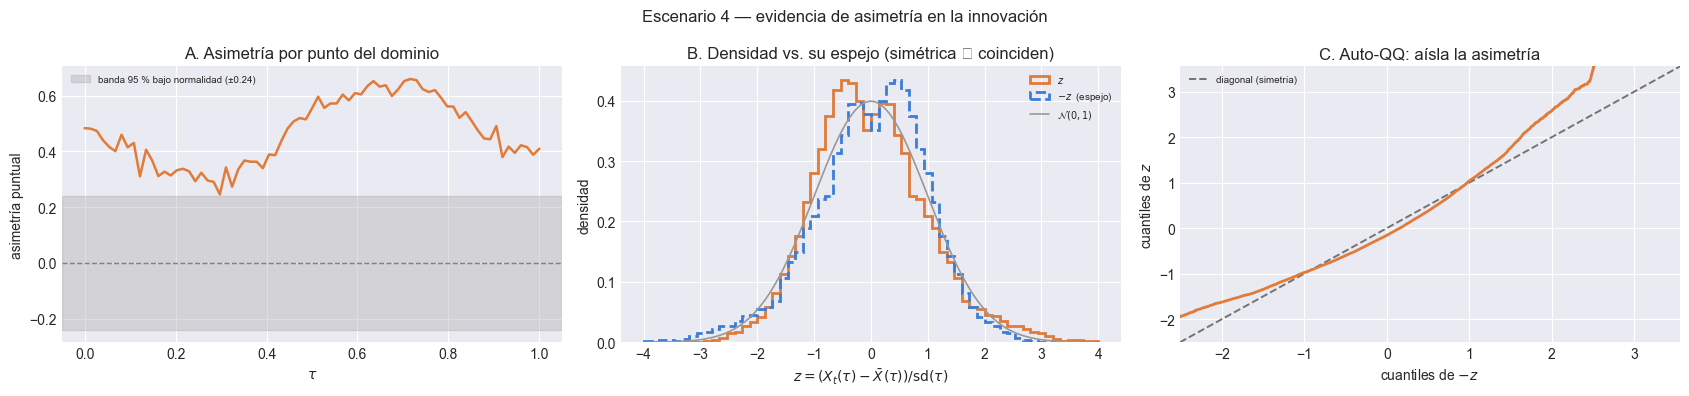

asimetría puntual  min/mediana/max : +0.246 / +0.447 / +0.660
banda 95 % bajo normalidad         : ±0.240   (= 1.96·sqrt(6/T), T=400)
puntos del dominio significativos  : 75 de 75   OK
asimetría agrupada (estand. por τ) : +0.468
asimetría de cuantiles             : 1.237    (1.0 = simétrica; la cola derecha es 24 % más larga)
media − mediana de z               : +0.0792   (>0 ⇒ cola derecha)

asimetría innovación (teórica)     : +0.4715
asimetría innovación (empírica)    : +0.4729
asimetría curvas (generador)       : +0.4788
razón curva/innovación             : 1.012

TECHO DE LA FAMILIA: con U_t = 1 (skew-normal pura, que es lo que fija el
anexo) el coeficiente de asimetría satura en ~0.96 cuando delta_skew → 1.
Con delta_skew = 0.9 se obtiene ~0.47.
Para más asimetría: subir delta_skew (0.95 → 0.67, 0.98 → 0.85), o cambiar
de familia a 'st'/'sl' — pero eso ya NO es el Algoritmo 4 del anexo, porque
añade peso de colas además de asimetría y deja de aislar el efecto.


In [29]:
# ── Diagnóstico de la asimetría (control del generador) ─────────────────────


_Xc   = X_raw - X_raw.mean(axis=0, keepdims=True)
_sd   = _Xc.std(axis=0, ddof=1)
_asim = (_Xc ** 3).mean(axis=0) / np.clip(_sd ** 3, 1e-12, None)   # por τ
_se   = np.sqrt(6.0 / T)                    # EE del coef. muestral bajo normalidad
_ban  = 1.96 * _se
_Z    = (_Xc / _sd).ravel()                 # estandarizado por τ y agrupado

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# A. Asimetría a lo largo del dominio, con banda de significancia
axes[0].axhspan(-_ban, _ban, color="0.65", alpha=0.35,
                label=f"banda 95 % bajo normalidad (±{_ban:.2f})")
axes[0].axhline(0.0, color="0.5", lw=1.0, ls="--")
axes[0].plot(domain.grid, _asim, color="#e07b39", lw=1.8)
axes[0].set_xlabel(r"$\tau$"); axes[0].set_ylabel("asimetría puntual")
axes[0].set_title("A. Asimetría por punto del dominio")
axes[0].legend(fontsize=7)

# B. Densidad contra su espejo: el hueco entre ambas ES la asimetría
_bins = np.linspace(-4.0, 4.0, 61)
axes[1].hist(_Z,  bins=_bins, density=True, histtype="step", lw=2.0,
             color="#e07b39", label=r"$z$")
axes[1].hist(-_Z, bins=_bins, density=True, histtype="step", lw=2.0,
             color="#3b7dd8", ls="--", label=r"$-z$  (espejo)")
_xx = np.linspace(-4, 4, 400)
axes[1].plot(_xx, np.exp(-0.5 * _xx ** 2) / np.sqrt(2 * np.pi),
             color="0.6", lw=1.2, label=r"$\mathcal{N}(0,1)$")
axes[1].set_xlabel(r"$z = (X_t(\tau)-\bar X(\tau))/\mathrm{sd}(\tau)$")
axes[1].set_ylabel("densidad")
axes[1].set_title("B. Densidad vs. su espejo (simétrica ⇒ coinciden)")
axes[1].legend(fontsize=7)

# C. Auto-QQ: cuantiles de z contra los de -z
_zs = np.sort(_Z)
_zm = np.sort(-_Z)
_lo, _hi = np.percentile(_Z, [0.2, 99.8])
axes[2].plot([_lo, _hi], [_lo, _hi], ls="--", color="0.45", lw=1.4,
             label="diagonal (simetría)")
axes[2].plot(_zm, _zs, color="#e07b39", lw=2.0)
axes[2].set_xlim(_lo, _hi); axes[2].set_ylim(_lo, _hi)
axes[2].set_xlabel(r"cuantiles de $-z$"); axes[2].set_ylabel(r"cuantiles de $z$")
axes[2].set_title("C. Auto-QQ: aísla la asimetría")
axes[2].legend(fontsize=7)

fig.suptitle("Escenario 4 — evidencia de asimetría en la innovación")
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "00_diagnostico_asimetria.png", dpi=150,
            bbox_inches="tight")
plt.show()

# ── Cifras de control ───────────────────────────────────────────────────────
_n_sig = int((_asim > _ban).sum())
_q10, _q50, _q90 = np.percentile(_Z, [10, 50, 90])
_qasim = (_q90 - _q50) / (_q50 - _q10)
_asim_pool = float(((_Z - _Z.mean()) ** 3).mean() / _Z.std(ddof=1) ** 3)

print(f"asimetría puntual  min/mediana/max : {_asim.min():+.3f} / "
      f"{np.median(_asim):+.3f} / {_asim.max():+.3f}")
print(f"banda 95 % bajo normalidad         : ±{_ban:.3f}   (= 1.96·sqrt(6/T), T={T})")
print(f"puntos del dominio significativos  : {_n_sig} de {len(_asim)}   "
      + ("OK" if _n_sig > 0.8 * len(_asim) else "← POCOS: la asimetría no es detectable"))
print(f"asimetría agrupada (estand. por τ) : {_asim_pool:+.3f}")
print(f"asimetría de cuantiles             : {_qasim:.3f}    "
      f"(1.0 = simétrica; la cola derecha es {100*(_qasim-1):.0f} % más larga)")
print(f"media − mediana de z               : {_Z.mean() - _q50:+.4f}   (>0 ⇒ cola derecha)")
print()
print(f"asimetría innovación (teórica)     : {salida.diagnostico['asimetria_innovacion_teorica']:+.4f}")
print(f"asimetría innovación (empírica)    : {salida.diagnostico['asimetria_innovacion_empirica']:+.4f}")
print(f"asimetría curvas (generador)       : {salida.diagnostico['asimetria_curvas_media']:+.4f}")
print(f"razón curva/innovación             : {salida.diagnostico['razon_asimetria_curva_innovacion']:.3f}")
print()
print("TECHO DE LA FAMILIA: con U_t = 1 (skew-normal pura, que es lo que fija el")
print("anexo) el coeficiente de asimetría satura en ~0.96 cuando delta_skew → 1.")
print(f"Con delta_skew = {SIM_CFG.delta_skew} se obtiene ~{salida.diagnostico['asimetria_innovacion_teorica']:.2f}.")
print("Para más asimetría: subir delta_skew (0.95 → 0.67, 0.98 → 0.85), o cambiar")
print("de familia a 'st'/'sl' — pero eso ya NO es el Algoritmo 4 del anexo, porque")
print("añade peso de colas además de asimetría y deja de aislar el efecto.")

## 2.2 Visualización de los datos empíricos

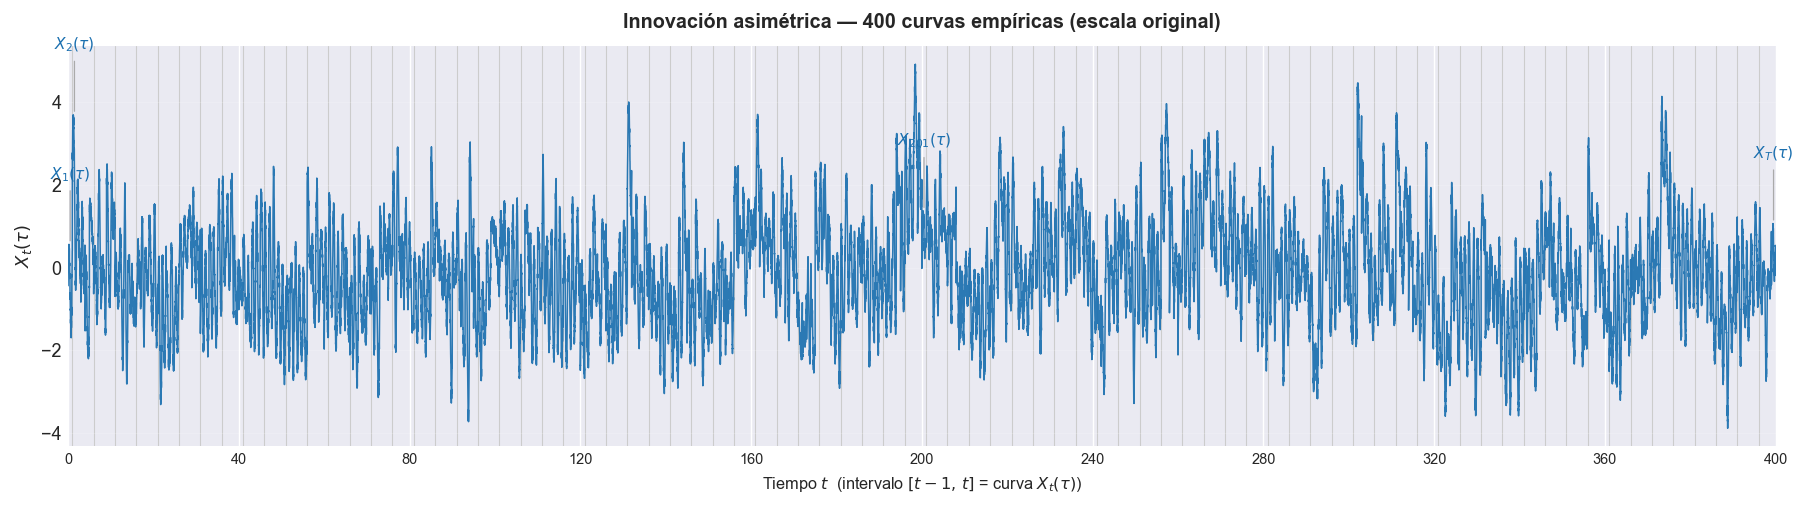

In [30]:
# ── Serie de tiempo funcional empírica ───────────────────────────────────────
highlight_idx = [0, 1, T // 2, T - 1]

fig = plot_fts_empirical(
    X_raw, domain.grid,
    highlight_idx   = highlight_idx,
    title           = f"Innovación asimétrica — {T} curvas empíricas (escala original)",
    separator_every = 5,
    save_path       = str(PATHS["out_report"] / "01_fts_empirica_raw.png"),
)
plt.show()

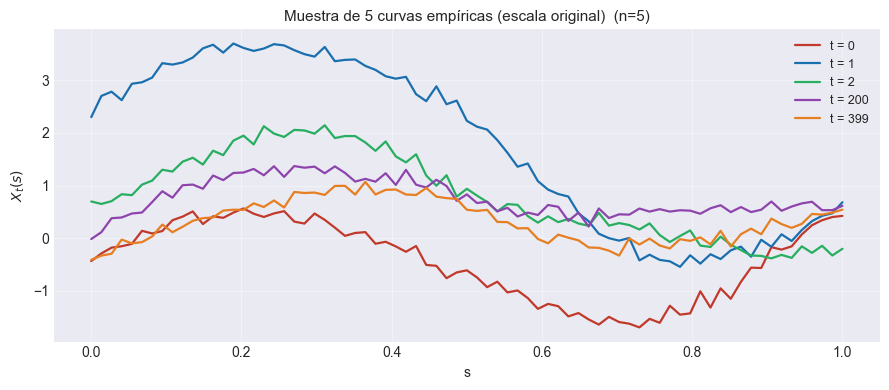

In [31]:
# ── Muestra de curvas empíricas ──────────────────────────────────────────────
fig = plot_empirical_sample(
    X_raw, domain.grid,
    sample_idx = [0, 1, 2, T // 2, T - 1],
    title      = "Muestra de 5 curvas empíricas (escala original)",
    save_path  = str(PATHS["out_report"] / "02_muestra_empirica_raw.png"),
)
plt.show()

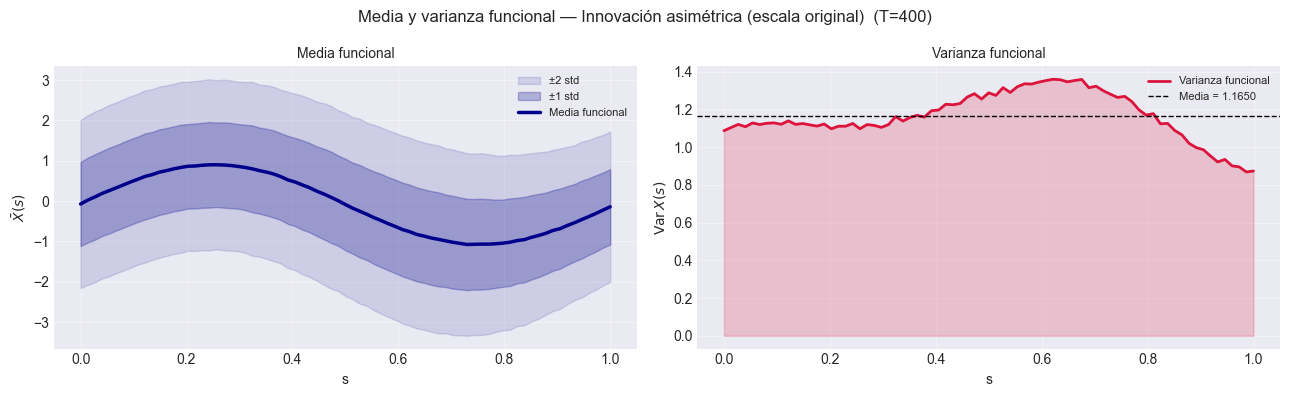

In [32]:
# ── Media y varianza funcional ───────────────────────────────────────────────
fig = plot_mean_and_variance(
    X_raw, domain.grid,
    show_std1 = True,
    show_std2 = True,
    title     = "Media y varianza funcional — Innovación asimétrica (escala original)",
    save_path = str(PATHS["out_report"] / "03_media_varianza_raw.png"),
)
plt.show()

## 2.3 Persistencia de datos crudos

In [33]:
X = X_raw   # alias para el resto del notebook

# guardar_curvas escribe X_curves.npy y domain_grid.npy en 'functional', que es
# donde el flujo de resultados los busca.
_p = guardar_curvas(PATHS, X, domain.grid)
print(f"[functional] X_curves.npy    {X.shape}")
print(f"[functional] domain_grid.npy {domain.grid.shape}")

[functional] X_curves.npy    (400, 75)
[functional] domain_grid.npy (75,)


## 2.4 Partición temporal de entrenamiento y prueba

La partición respeta el orden de la serie: todo objeto **estimado a partir de
los datos** (selección GCV de la base, FPCA, estandarizador) se ajusta
exclusivamente con el bloque inicial $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`. El bloque de prueba queda reservado para la
evaluación fuera de muestra.

In [34]:
# ── Partición temporal (holdout) ─────────────────────────────────────────────
PROP_TRAIN   = 0.70
T0 = int(np.floor(PROP_TRAIN * T))         # nº de curvas de entrenamiento

assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train = np.arange(0, T0)
idx_test  = np.arange(T0, T)
X_train, X_test = X[idx_train], X[idx_test]

print("Partición temporal (holdout):")
print(f"  entrenamiento : t ∈ [1, {T0}]      →  {X_train.shape}")
print(f"  prueba        : t ∈ [{T0+1}, {T}]  →  {X_test.shape}")
print(f"  proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

Partición temporal (holdout):
  entrenamiento : t ∈ [1, 280]      →  (280, 75)
  prueba        : t ∈ [281, 400]  →  (120, 75)
  proporción    : 70.0% / 30.0%


# 3. Representación funcional B-spline

In [35]:
# SELECCIÓN DE PARÁMETROS DE LA REPRESENTACIÓN FUNCIONAL (n_basis, order)
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # [HOLDOUT] rango acotado por T0
ORDER_RANGE   = range(2, 5)
selection_records = []

for order_bs in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < order_bs:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=order_bs)
            TH_tmp = fr_tmp.fit_transform(X_train, domain.grid)   # [HOLDOUT] solo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            vr     = 1.0 - sse_c.sum() / ss_tot
            rmse_c = np.sqrt(sse_c / L_i)
            df_k   = nb
            gcv_c  = (L_i * sse_c / (L_i - df_k) ** 2
                      if L_i > df_k else np.full_like(sse_c, np.nan))

            selection_records.append({
                "n_basis": nb, "order": order_bs, "var_retained": vr,
                "rmse_mean": rmse_c.mean(), "rmse_max": rmse_c.max(),
                "gcv_mean": float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={order_bs}: {e}")

sel_df = pd.DataFrame(selection_records)

# ── Criterio: mínimo de GCV promedio sobre las curvas ────────────────────────
sel_valid = sel_df.dropna(subset=["gcv_mean"])
best_row  = sel_valid.loc[sel_valid["gcv_mean"].idxmin()]
nb_best   = int(best_row["n_basis"])
ord_best  = int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"],     cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn")
    .background_gradient(subset=["rmse_mean"],    cmap="YlOrRd_r"))

print(f"\nSelección por GCV mínimo: n_basis={nb_best}, order={ord_best}, "
      f"GCV={best_row['gcv_mean']:.6f}")
print(f"Verificación descriptiva: var_retained={best_row['var_retained']:.4%}, "
      f"rmse_mean={best_row['rmse_mean']:.6f}, rmse_max={best_row['rmse_max']:.6f}")

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,69.7054%,0.553477,1.115534,0.358806
1,3,2,77.2153%,0.472833,1.054597,0.277407
2,4,2,95.9965%,0.203790,0.415782,0.050126
3,5,2,97.9035%,0.149872,0.291678,0.027005
4,6,2,98.6927%,0.120012,0.179183,0.017331
5,7,2,98.9785%,0.106571,0.145938,0.013943
6,8,2,99.0843%,0.100941,0.135830,0.012875
7,9,2,99.1399%,0.097845,0.126733,0.012462
8,10,2,99.1805%,0.095509,0.124272,0.012243
9,11,2,99.2036%,0.094141,0.127018,0.012271



Selección por GCV mínimo: n_basis=9, order=4, GCV=0.011673
Verificación descriptiva: var_retained=99.1944%, rmse_mean=0.094716, rmse_max=0.130474


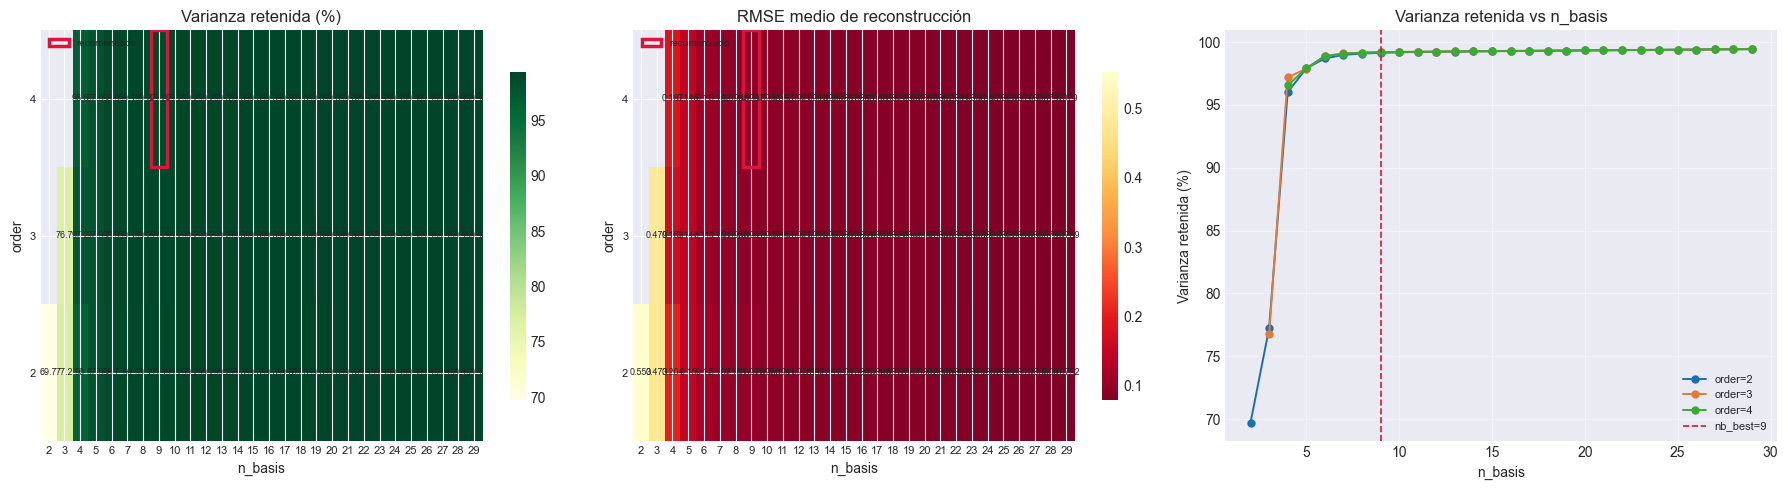

In [36]:
fig = plot_seleccion_basis(
    sel_df, nb_best, ord_best,
    save_path=str(PATHS["out_report"] / "08_seleccion_basis.png"),
)
plt.show()

## 3.1 Ajuste y visualización de la representación funcional

Base elegida  : n_basis=9, order=4
Sugerido GCV  : n_basis=9, order=4   (coinciden)
THETA shape: (400, 9)  (train=280, test=120)


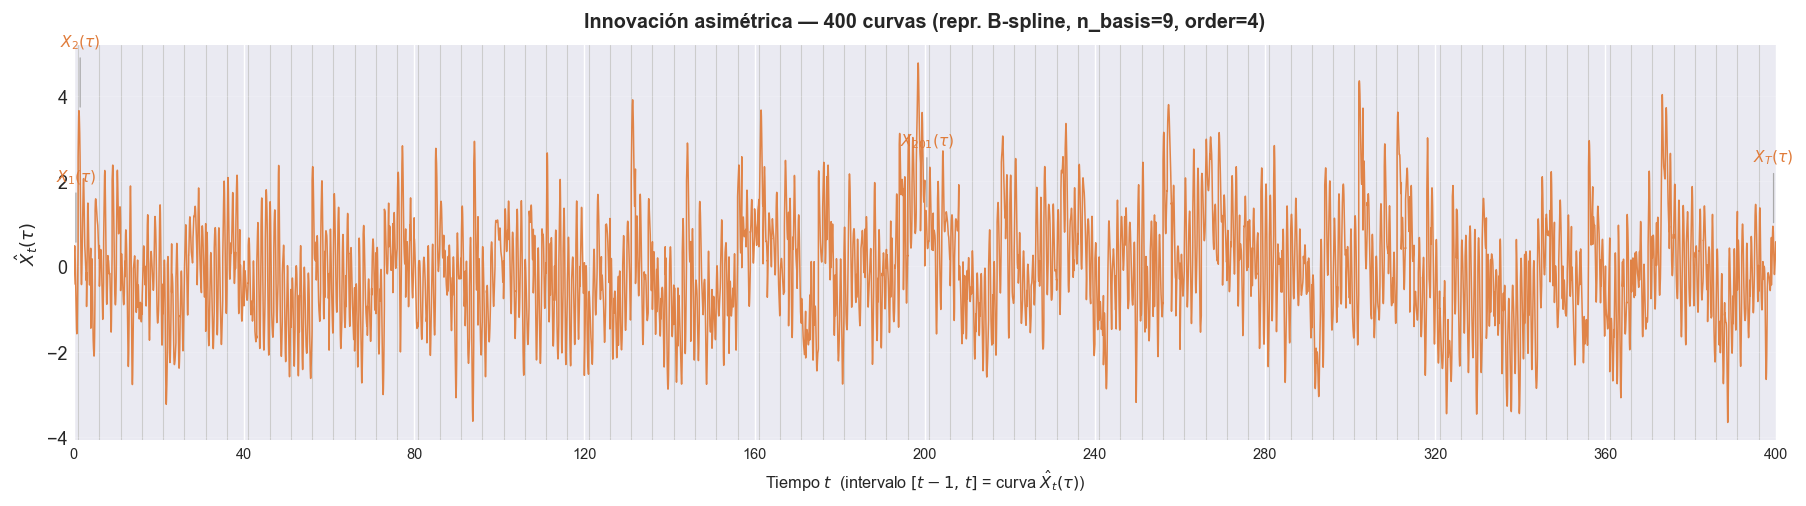

[functional] functional_representation.pkl + theta.csv + fr_config.json


In [37]:
# CONSTANTES ELEGIDAS PARA LA REPRESENTACIÓN FUNCIONAL
# La elección es una decisión del analista: el GCV la SUGIERE, no la fija.
NB_ELEGIDO  = nb_best     # ← fíjalo TÚ si quieres apartarte del GCV
ORD_ELEGIDO = ord_best
print(f"Base elegida  : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV  : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

# center=False es imprescindible y por eso se declara de forma explícita. Con
# center=True, `reconstruct` es el mapa AFÍN Theta Phi^T + media en lugar del
# lineal, y la función media contamina la base recuperada por `base_en_grilla`,
# la matriz de Gram y las autofunciones.
fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)

# [HOLDOUT] Ajuste SOLO con entrenamiento; proyección de toda la serie.
fr.fit(X_train, domain.grid)
THETA       = fr.transform(X, domain.grid)            # (T, K)
THETA_train = THETA[idx_train]
print(f"THETA shape: {THETA.shape}  (train={THETA_train.shape[0]}, test={T - T0})")

fig = plot_fts_functional(
    X, domain.grid,
    fr              = fr,
    highlight_idx   = highlight_idx,
    title           = f"Innovación asimétrica — {T} curvas (repr. B-spline, n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})",
    separator_every = 5,
    save_path       = str(PATHS["out_report"] / "09_fts_funcional_bspline.png"),
)
plt.show()

guardar_representacion(PATHS, fr, THETA,
                       extra={"T0": int(T0), "prop_train": float(PROP_TRAIN),
                              "ajustado_en": "train", "center": bool(fr.center),
                              "n_basis": int(NB_ELEGIDO), "order": int(ORD_ELEGIDO),
                              "n_basis_gcv": int(nb_best), "order_gcv": int(ord_best)})
print("[functional] functional_representation.pkl + theta.csv + fr_config.json")

## 3.2 FPCA sobre la base seleccionada

Verificación FPCA_L2 (sobre entrenamiento):
  M                                  = 9
  K                                  = 9
  n_ajuste                           = 280
  cond_W                             = 2.692e+01
  err_ortonormalidad_L2              = 3.109e-15
  err_ortonormalidad_gram            = 2.442e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.816e-16
  err_media_scores_rel               = 2.112e-15
  err_var_scores_vs_lambda           = 1.388e-16
  err_var_scores_vs_lambda_rel       = 3.519e-13
  err_correlacion_lag0               = 2.887e-13
  criterios_evaluados                = 7 criterios
  todo_ok                            = True

cond(W) = 2.692e+01  (condicionamiento sano)


,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,8.8246e-01,78.8161%,78.8161%,+0.487
1,2,1.2674e-01,11.3198%,90.1359%,+0.262
2,3,7.3920e-02,6.6021%,96.7380%,-0.017
3,4,2.3985e-02,2.1422%,98.8802%,+0.093
4,5,8.5428e-03,0.7630%,99.6432%,-0.047
5,6,2.8209e-03,0.2519%,99.8951%,-0.050
6,7,8.0756e-04,0.0721%,99.9673%,+0.043
7,8,2.1429e-04,0.0191%,99.9864%,-0.016
8,9,1.5237e-04,0.0136%,100.0000%,+0.039



K B-spline disponibles : 9
SUGERENCIA (var ≥ 95%) : M_SUGGERIDO = 3   ← solo referencia; fija M_FPCA en la celda 3.3


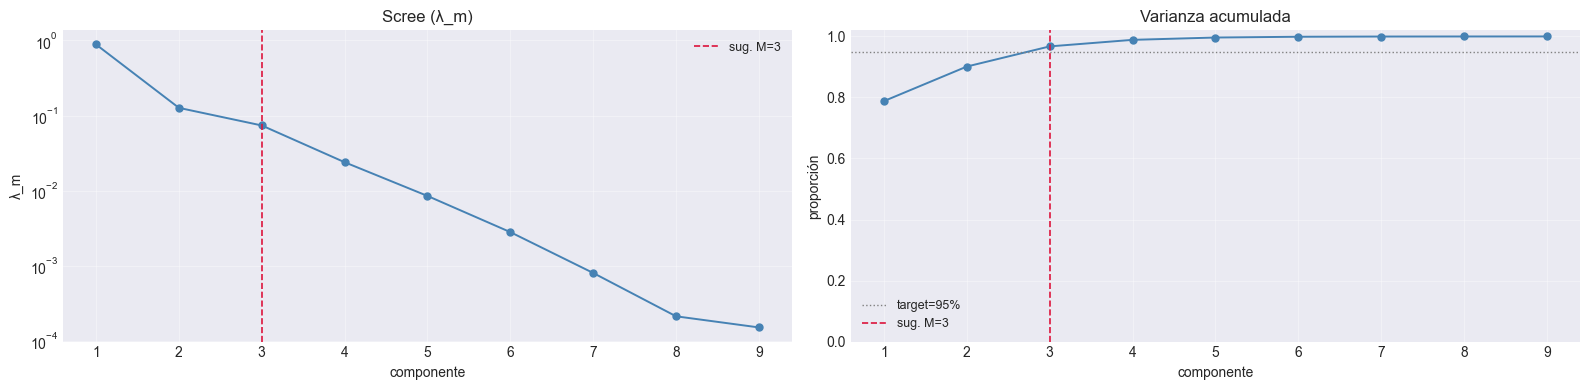

In [38]:
# FPCA GENERALIZADO en métrica L² (functions_models.FPCA_L2).
# Base B-spline NO ortonormal ⇒ Gram W = <φ_j,φ_k>_{L²} ≠ I, de modo que la
# descomposición correcta resuelve el problema propio generalizado
#     (W^{1/2} S_θ W^{1/2}) z = λ z,   con ‖ψ_m‖_{L²} = 1.
# [HOLDOUT] el ajuste emplea SOLO el bloque de entrenamiento.

Phi  = base_en_grilla(fr, THETA.shape[1])          # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, domain.grid)

_ver = fpca.verificar(THETA_train, fr=fr)

print("Verificación FPCA_L2 (sobre entrenamiento):")
for _k, _v in _ver.items():
    if isinstance(_v, float):
        print(f"  {_k:34s} = {_v:.3e}")
    elif isinstance(_v, (list, tuple)):
        print(f"  {_k:34s} = {len(_v)} criterios")
    else:
        print(f"  {_k:34s} = {_v}")

_cond = _ver["cond_W"]
print(f"\ncond(W) = {_cond:.3e}", end="  ")
if _cond > 1e10:
    print("← MUY ALTO: reduzca n_basis o revise el solapamiento de la base")
elif _cond > 1e6:
    print("← alto: vigile las componentes de menor varianza")
else:
    print("(condicionamiento sano)")

assert _ver["todo_ok"], (
    "Las identidades del FPCA generalizado no se cumplen. Si falla "
    "`err_linealidad_reconstruct_rel`, revise que la representación se haya "
    "ajustado con center=False."
)

# ── Diagnóstico dinámico: AR(1) propio de cada componente (≠ varianza) ───────
# Varianza = representación; AR(1) = dinámica. Una FPC de varianza baja puede
# tener AR fuerte (útil para pronóstico) y una de varianza alta puede ser ruido
# temporal. Esta distinción es el eje del Escenario 5.
K = fpca.evals.size
_Bf = fpca.B_full
SCORES_all = (THETA_train - fpca.mu_theta) @ (fpca.W @ _Bf)   # (T0, K)
s0, s1 = SCORES_all[:-1], SCORES_all[1:]
ar1_own = (s1 * s0).sum(0) / np.clip((s0 * s0).sum(0), 1e-12, None)

evals, var_cum = fpca.evals, fpca.var_cum
VAR_TARGET  = 0.95
M_SUGGERIDO = fpca.seleccionar_M(VAR_TARGET)

fpca_tbl = pd.DataFrame({
    "componente": np.arange(1, K + 1),
    "autovalor":  evals,
    "var_ratio":  fpca.var_ratio,
    "var_acum":   var_cum,
    "ar1_propio": ar1_own,
})
display(fpca_tbl.head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}", "var_acum": "{:.4%}",
     "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))
print(f"\nK B-spline disponibles : {K}")
print(f"SUGERENCIA (var ≥ {VAR_TARGET:.0%}) : M_SUGGERIDO = {M_SUGGERIDO}   "
      f"← solo referencia; fija M_FPCA en la celda 3.3")

fig = plot_fpca_scree(
    evals, var_cum, M_SUGGERIDO, var_target=VAR_TARGET,
    save_path=str(PATHS["out_report"] / "10_fpca_scree.png"),
)
plt.show()

## 3.3 Fijar el número de componentes retenidas

In [39]:
M_FPCA = int(M_SUGGERIDO)   # ← nº de componentes FPCA a retener (lo fijas TÚ)

assert isinstance(M_FPCA, (int, np.integer)) and 1 <= M_FPCA <= fpca.evals.size, (
    f"M_FPCA debe ser entero en [1, {fpca.evals.size}]. Recibido: {M_FPCA!r}"
)
fpca.set_M(int(M_FPCA))
M_fpca = fpca.M

# ── Objetos derivados ────────────────────────────────────────────────────────
Psi_grid = fpca.Psi_grid          # (G, M) autofunciones ortonormales en L²
mu_grid  = fpca.mu_grid           # (G,)
W        = fpca.W                 # (K, K) Gram
B        = fpca.B                 # (K, M)
mu_theta = fpca.mu_theta          # (K,)

# [HOLDOUT] scores de TODA la serie proyectados sobre la base de entrenamiento
SCORES       = fpca.transform(THETA)          # (T, M)
SCORES_train = SCORES[idx_train]
SCORES_test  = SCORES[idx_test]

print(f"M_fpca = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
print(f"[train] max|media ξ|  = {np.abs(SCORES_train.mean(0)).max():.2e}   (≈ 0)")
print(f"[test]  max|media ξ|  = {np.abs(SCORES_test.mean(0)).max():.3f}")
print(f"[test]  var ξ / λ     = "
      f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

# La FPCA se persiste en §4.0, junto con los scores estandarizados, para que
# SCORES y SCORES_STD queden escritos en una única operación consistente.
print("\n[nota] la FPCA se persiste en §4.0, junto con los scores estandarizados.")

M_fpca = 3   var. explicada = 96.7380%
[train] max|media ξ|  = 2.82e-16   (≈ 0)
[test]  max|media ξ|  = 0.214
[test]  var ξ / λ     = [1.11  1.048 0.96 ]

[nota] la FPCA se persiste en §4.0, junto con los scores estandarizados.


# 4. Construcción de datasets AR(p) sobre scores de FPCA

## 4.0 Estandarización de scores ξ 


[holdout] estandarizador ajustado con 280 filas = T0 (train[1:280])  →  ok=True
Metodo: zscore_column
Features: 3
Filas de ajuste: 280  (train[1:280])
  Media: min=-0.0000, max=0.0000
  Std:   min=0.2714, max=0.9377
SCORES_STD : shape=(400, 3)  (train=280, test=120)
  [train] max|media| = 9.85e-17
  [train] max|std-1| = 2.22e-16
  [test]  media      = [ 0.228 -0.116  0.195]
  [test]  std        = [1.051 1.021 0.978]
[functional] artefactos FPCA + fpca_scores_std.csv + scores_standardizer/
             cond_W persistido = 2.692e+01


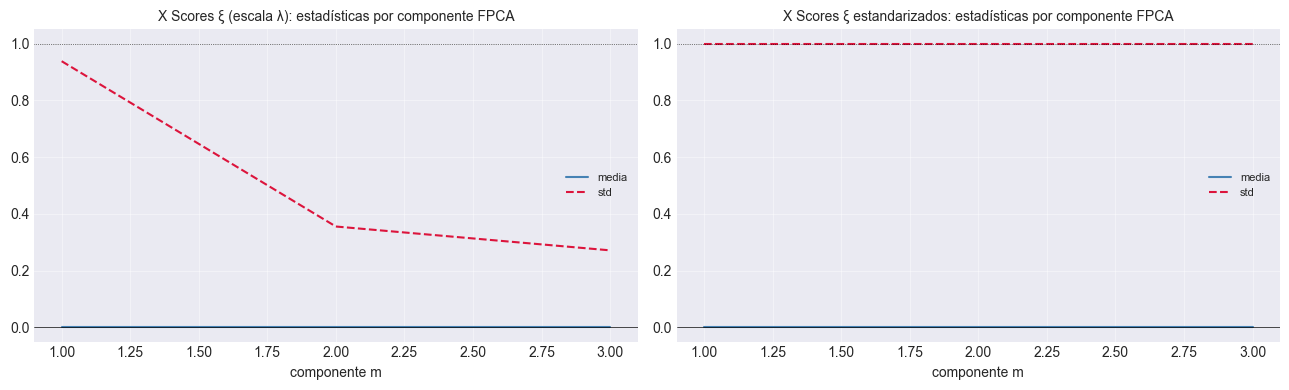

In [40]:
# [HOLDOUT] El ajuste emplea SOLO el bloque de entrenamiento. `etiqueta` y el
# registro interno `n_ajuste` convierten esa disciplina en una propiedad
# VERIFICABLE.
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

_chk_std = scores_standardizer.verificar_ajuste(T0)
print(f"[holdout] estandarizador ajustado con {_chk_std['n_ajuste']} filas "
      f"= T0 ({_chk_std['etiqueta_ajuste']})  →  ok={_chk_std['ajuste_ok']}")

SCORES_STD       = scores_standardizer.transform(SCORES)
SCORES_STD_train = SCORES_STD[idx_train]
SCORES_STD_test  = SCORES_STD[idx_test]

print(scores_standardizer.summary())
print(f"SCORES_STD : shape={SCORES_STD.shape}  (train={T0}, test={T - T0})")
print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}")
print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}")
print(f"  [test]  media      = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
print(f"  [test]  std        = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

# ── Persistencia (contrato de artefactos) ────────────────────────────────────
guardar_estandarizador(PATHS, scores_standardizer)
_res_fpca = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                         meta_extra={"T0": int(T0)})
print("[functional] artefactos FPCA + fpca_scores_std.csv + scores_standardizer/")
print(f"             cond_W persistido = {_res_fpca['meta']['cond_W']:.3e}")

fig = plot_diagnostico_estandarizacion(
    SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "04_diagnostico_estandarizacion_scores.png"),
)
fig.axes[0].set_xlabel("componente m"); fig.axes[1].set_xlabel("componente m")
plt.show()

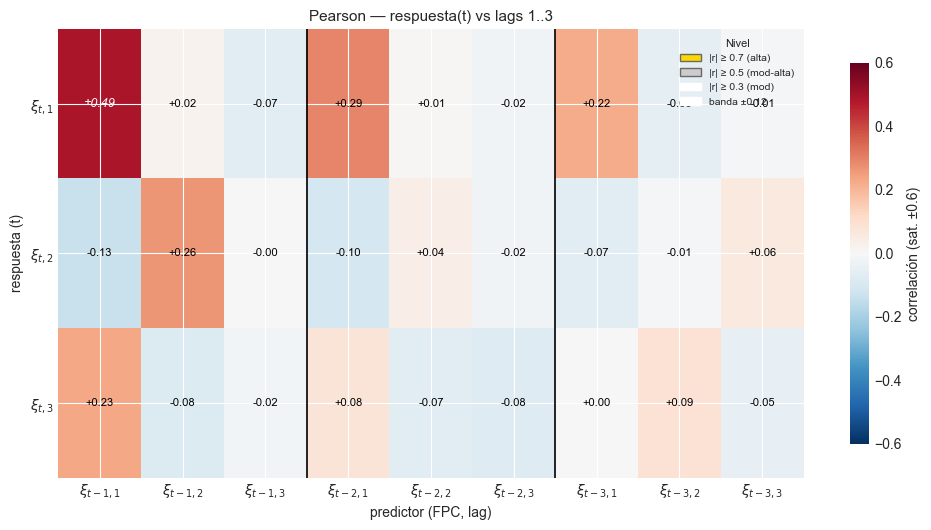

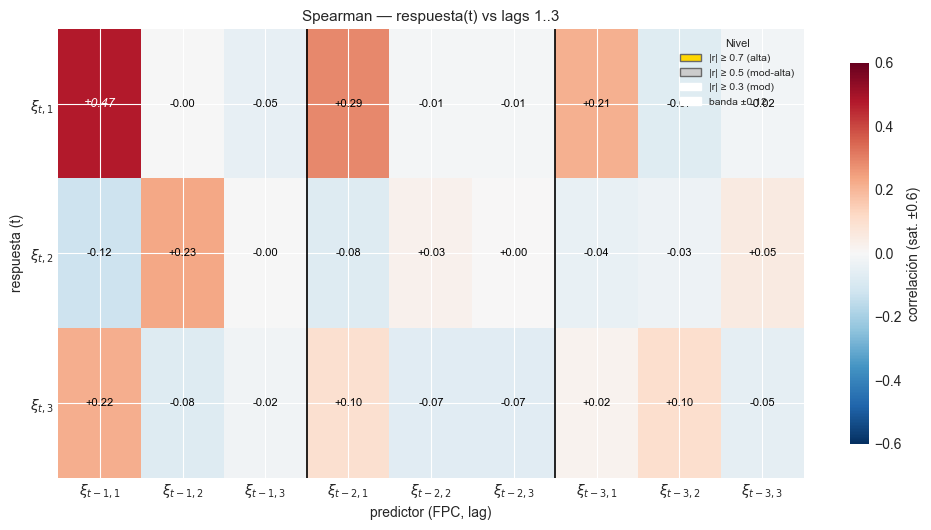

In [41]:
# [HOLDOUT] la elección de rezagos es una decisión de modelado: solo train
T_theta = SCORES_STD_train.shape[0]
K_total = SCORES_STD_train.shape[1]

N_LAGS_MAX = 3
N_LAGS_MAX = int(np.clip(N_LAGS_MAX, 1, T_theta - 2))

def _spearman_block(Y, X):
    """Spearman columna-a-columna vía rangos (pandas; sin scipy)."""
    Yr = pd.DataFrame(Y).rank().to_numpy()
    Xr = pd.DataFrame(X).rank().to_numpy()
    Yc = Yr - Yr.mean(0); Xc = Xr - Xr.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

n_cov = K_total * N_LAGS_MAX
corr_pearson  = np.zeros((K_total, n_cov))
corr_spearman = np.zeros((K_total, n_cov))
col_labels = []
y_block = SCORES_STD_train[N_LAGS_MAX:, :]

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
    sp = _spearman_block(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_pearson[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_spearman[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band  = 1.96 / np.sqrt(len(y_block))
VCLIP = 0.6

fig = plot_rezagos_heatmap(
    corr_pearson, col_labels, row_labels,
    title=f"Pearson — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12a_rezagos_pearson.png"),
)
plt.show()

fig = plot_rezagos_heatmap(
    corr_spearman, col_labels, row_labels,
    title=f"Spearman — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12b_rezagos_spearman.png"),
)
plt.show()

## 4.1 Selección de rezagos y dataset final

In [42]:
N_LAGS  = 1
K_total = SCORES_STD.shape[1]
COMPONENT_IDX = list(range(K_total))

n_train_eff = T0 - N_LAGS            # respuestas en t = N_LAGS+1 … T0
n_test_eff  = T - T0                 # respuestas en t = T0+1 … T

assert T0 > N_LAGS, f"T0={T0} debe superar N_LAGS={N_LAGS}."
assert len(COMPONENT_IDX) > 0, "COMPONENT_IDX no puede estar vacío."
assert len(COMPONENT_IDX) == len(set(COMPONENT_IDX)), "COMPONENT_IDX repetidos."
assert all(0 <= i < K_total for i in COMPONENT_IDX), "Índices fuera de rango."

n_components = len(COMPONENT_IDX)

print(f"K_total disponibles : {K_total}  (índices 0 … {K_total - 1})")
print(f"T / T0              : {T} / {T0}")
print(f"N_LAGS              : {N_LAGS}")
print(f"n_train_eff         : {n_train_eff}")
print(f"n_test_eff          : {n_test_eff}")
print()
print(f"  {'k_modelo':>8}  {'idx_THETA':>10}  {'nombre_resp':>14}")
print(f"  {'─'*8}  {'─'*10}  {'─'*14}")
for k_model, idx in enumerate(COMPONENT_IDX):
    print(f"  {k_model:>8}  {idx:>10}  {'fpc_' + str(idx + 1):>14}")

K_total disponibles : 3  (índices 0 … 2)
T / T0              : 400 / 280
N_LAGS              : 1
n_train_eff         : 279
n_test_eff          : 120

  k_modelo   idx_THETA     nombre_resp
  ────────  ──────────  ──────────────
         0           0           fpc_1
         1           1           fpc_2
         2           2           fpc_3


In [43]:
# ── Construcción de DataFrames AR(p): bloques de entrenamiento y prueba ──────
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

cov_names = [
    f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
    for lag in range(1, N_LAGS + 1)
    for j in range(n_components)
]

def _dataset_bloque(k: int, t_ini: int, t_fin: int) -> pd.DataFrame:
    """
    Filas con respuesta en t ∈ [t_ini, t_fin) y predictores en t-1 … t-N_LAGS.

    Los rezagos del primer origen de prueba provienen del final del bloque de
    entrenamiento: son observaciones pasadas disponibles en cada origen, de modo
    que su uso es el condicionamiento que prescribe §2.2.3.1 (predicción a
    horizonte h=1 con la historia observada), no fuga de información.
    """
    t_idx  = np.arange(t_ini, t_fin)
    y_col  = SCORES_sel[t_idx, k]
    X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
    return pd.DataFrame(np.column_stack([y_col, X_cols]),
                        columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

dfs_train, dfs_test = {}, {}
for k in range(n_components):
    dfs_train[k] = _dataset_bloque(k, N_LAGS, T0)
    dfs_test[k]  = _dataset_bloque(k, T0,     T)

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "T":             int(T),
    "T0":            int(T0),
    "prop_train":    float(PROP_TRAIN),
    "n_train_eff":   int(n_train_eff),
    "n_test_eff":    int(n_test_eff),
    "ajuste_en":     "train",
}
guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
print(f"[functional] {2*n_components} datasets (train/test) + datasets_manifest.json")

[functional] 6 datasets (train/test) + datasets_manifest.json


# 5. Especificación de hiperparámetros y ajuste MCMC

In [45]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 50, "M": 50}
N_CHAINS    = 3
BURN        = int(MCMC_CONFIG["burn"])
print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS}  (cadenas que ejecutará MATLAB)")
print()
print("Recordatorio: en `mcmc_config`, `M` es el tamaño de la grilla de")
print("localización G* del stick-breaking y `N` el truncamiento del número de")
print("átomos. NO confundir con M_FPCA (componentes retenidas).")

MCMC_CONFIG : {'nsim': 2000, 'burn': 500, 'N': 50, 'M': 50}
N_CHAINS    : 3  (cadenas que ejecutará MATLAB)

Recordatorio: en `mcmc_config`, `M` es el tamaño de la grilla de
localización G* del stick-breaking y `N` el truncamiento del número de
átomos. NO confundir con M_FPCA (componentes retenidas).


In [46]:
# ════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS — priors heterogéneas por tipo de variable
# ════════════════════════════════════════════════════════════════════════════

HP_GLOBAL = {
    "atau":  2.0,
    "btau":  0.5,
    "ag":    2.0,
    "bg":    0.5,
    "mumu":  0.0,
    "taumu": 1.0,
    "pwj":   0.5,
}

#   Formato: "tipo": (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0,  0.0, 1.0),   # E[π] = 0.90
    "cross_lag": (1.0, 1.0,  0.0, 1.0),   # E[π] = 0.50
}

def _classify(name: str, k_model: int, component_idx: list) -> str:
    own_name = f"fpc_{component_idx[k_model] + 1}_lag1"
    if name == own_name:
        return "own_lag1"
    return "cross_lag"

HYPERPARAMS_LIST = []
for k in range(n_components):
    p = len(cov_names)
    apij    = np.empty(p); bpij    = np.empty(p)
    mupsij  = np.empty(p); taupsij = np.empty(p)

    for j, name in enumerate(cov_names):
        vtype         = _classify(name, k, COMPONENT_IDX)
        a, b, mu, tau = HP_BY_TYPE[vtype]
        apij[j]   = a;  bpij[j]    = b
        mupsij[j] = mu; taupsij[j] = tau

    HYPERPARAMS_LIST.append({**HP_GLOBAL,
                             "apij": apij,     "bpij": bpij,
                             "mupsij": mupsij, "taupsij": taupsij})

_W = 70
print("═" * _W)
print(f"  HYPERPARAMS_LIST  —  {n_components} componentes × {p} variables")
print("═" * _W)
print(f"  Globales: atau={HP_GLOBAL['atau']} btau={HP_GLOBAL['btau']}  "
      f"ag={HP_GLOBAL['ag']} bg={HP_GLOBAL['bg']}  "
      f"mumu={HP_GLOBAL['mumu']} taumu={HP_GLOBAL['taumu']}  "
      f"pwj={HP_GLOBAL['pwj']}")
print()
for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"  Componente k={k+1}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'Variable':<26} {'Tipo':<12} {'apij':>6} {'bpij':>6} "
          f"{'E[π]':>6} {'mupsij':>8} {'taupsij':>9}")
    print(f"  {'─'*26} {'─'*12} {'─'*6} {'─'*6} {'─'*6} {'─'*8} {'─'*9}")
    for j, name in enumerate(cov_names):
        vtype = _classify(name, k, COMPONENT_IDX)
        a  = hp["apij"][j];    b   = hp["bpij"][j]
        mu = hp["mupsij"][j];  tau = hp["taupsij"][j]
        e_pi = a / (a + b)
        marker = "  ◄" if vtype == "own_lag1" else ""
        print(f"  {name:<26} {vtype:<12} {a:>6.1f} {b:>6.1f} "
              f"{e_pi:>6.3f} {mu:>8.1f} {tau:>9.1f}{marker}")
    print()

══════════════════════════════════════════════════════════════════════
  HYPERPARAMS_LIST  —  3 componentes × 3 variables
══════════════════════════════════════════════════════════════════════
  Globales: atau=2.0 btau=0.5  ag=2.0 bg=0.5  mumu=0.0 taumu=1.0  pwj=0.5

  Componente k=1  (fpc_1)
  Variable                   Tipo           apij   bpij   E[π]   mupsij   taupsij
  ────────────────────────── ──────────── ────── ────── ────── ──────── ─────────
  fpc_1_lag1                 own_lag1        9.0    1.0  0.900      0.0       1.0  ◄
  fpc_2_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_3_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0

  Componente k=2  (fpc_2)
  Variable                   Tipo           apij   bpij   E[π]   mupsij   taupsij
  ────────────────────────── ──────────── ────── ────── ────── ──────── ─────────
  fpc_1_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_2_lag1        

In [47]:
# ── Guardar hiperparámetros del modelo en artefact ───────────────────────────
hp_artifact = {
    "global":       HP_GLOBAL,
    "by_type":      HP_BY_TYPE,
    "mcmc_config":  MCMC_CONFIG,
    "n_iter":       N_CHAINS,
    "seed_scheme":  "SEED_BASE + chain*9973 + k*31",
    "escenario_id": int(ESCENARIO_ID),
    "replica_id":   int(REPLICA_ID),
    "seed_base":    SEED,
    "scores_scale": "standardized_zscore_ddof0",
    # [HOLDOUT] partición temporal — MATLAB entrena SOLO con *_train.csv
    "partition": {
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                        for k in range(n_components)],
        "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                        for k in range(n_components)],
    },
    "hyperparams_list": []
}

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k].copy()
    hp_artifact["hyperparams_list"].append({
        "component_k": k,
        "fpc_idx": int(COMPONENT_IDX[k] + 1),
        "hyperparams": {
            key: value.tolist() if isinstance(value, np.ndarray) else value
            for key, value in hp.items()
        }
    })

guardar_hiperparametros(PATHS, hp_artifact)
print(f"✓ Hiperparámetros guardados en: {PATHS['out_artefact'] / 'hyperparameters.json'}")
print()
print("SIGUIENTE PASO — MATLAB:")
print(f"  1. cd a notebooks/simulaciones/08_sim_E4")
print(f"  2. ejecutar psbp_fd_iteracion.m  (ESCENARIO_ID = 4 ya fijado)")
print(f"  3. volver a 08_03_resultados.ipynb")

✓ Hiperparámetros guardados en: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_4\hyperparameters.json

SIGUIENTE PASO — MATLAB:
  1. cd a notebooks/simulaciones/08_sim_E4
  2. ejecutar psbp_fd_iteracion.m  (ESCENARIO_ID = 4 ya fijado)
  3. volver a 08_03_resultados.ipynb


# 6. Configuración de evaluación y líneas base (bloque de prueba)


In [48]:
# ── Configuración de evaluación (la consume el flujo de resultados) ──────────
eval_config = {
    "scheme":         "holdout_temporal",
    "T":              int(T),
    "T0":             int(T0),
    "prop_train":     float(PROP_TRAIN),
    "horizons":       [1],                    # h=1 vía dataset_test; h>1: simulación
    "n_lags":         int(N_LAGS),
    "metrics_scores": ["RMSE", "R2"],
    # Error puntual en forma integrada (decisión cerrada del estudio):
    # MISE y MIAE son medias del error integrado por curva; `peor_curva` es su
    # máximo SOBRE CURVAS, no sobre puntos del dominio.
    "metrics_curvas": ["MISE", "MIAE", "RMSE_funcional", "peor_curva"],
    "metrics_dist":   ["LPS", "CRPS", "cobertura_95", "PIT"],
    # Dos objetivos de evaluación, ambos SIN ruido de medición:
    #   proyectada = fpca.reconstruct(scores observados)  → modo_residuo="ninguno"
    #   representacion = fr.reconstruct(theta observados)
    "objetivos_evaluacion": ["proyectada", "representacion"],
    "modo_residuo":   "ninguno",
    "scores_scale":   "standardized_zscore_ddof0",
}
guardar_config_evaluacion(PATHS, eval_config)
print("[out_artefact] eval_config.json")

# ── Líneas base sobre el bloque de prueba (h=1) ──────────────────────────────
baselines_df = tabla_baselines(
    SCORES_STD, T0,
    estandarizador=scores_standardizer,
    fpca=fpca,
    X_obs=X,
    tau=domain.grid,
    h=1,
)
baselines_df.to_csv(PATHS["out_report"] / "32_baselines_test.csv")
print("[out_report] 32_baselines_test.csv")
display(baselines_df.style.format("{:.4f}", na_rep="—")
        .set_caption("Líneas base — bloque de prueba, h=1 "
                     "(piso que el PSBP-FD debe superar)"))

# ── Verificación cruzada del contrato de artefactos ──────────────────────────
informe = verificar_contrato(PATHS)
print(f"\ncontrato_ok = {informe['contrato_ok']}  "
      f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
      f"n_components={informe['n_components']})")
print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
      f"(T0 = {informe['T0']})")
print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
assert informe["contrato_ok"], "El contrato de artefactos NO es consistente."
print("\n✓ Artefactos listos para MATLAB.")

[out_artefact] eval_config.json
[out_report] 32_baselines_test.csv


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,120.0000,1.0752,1.0278,0.9968,1.0333,-0.0331,1.2727,1.1281
persistencia_lag1,120.0000,1.0931,1.3106,1.2498,1.2178,-0.4544,1.4320,1.1967



contrato_ok = True  (M=3, K=9, T0=280, n_components=3)
estandarizador ajustado con 280 filas (T0 = 280)
verificación FPCA: todo_ok = True

✓ Artefactos listos para MATLAB.
